## T1 - Load the Data and Orient Yourself

Project 1 focused on data exploration on already classified data, we had columns telling us what kind of attack each connection represented, this was determined by someone who classified the data based on the features - example being DoS attacks classified as such because of their low byte count, short duration and high intensity in short periods of time.

In this project we will focus on supervised learning, we will give the model labelled examples ( features + correct answer ) and train the model based on that pattern. The model should successfully predict new data it's never seen based on its training. This is different from project 1, we're not doing data exploration anymore, we're creating a supervised learning pipeline.

This model will predict cancer based on previous biopsies - either malignant or benign. The predictions will be made by analyzing 30 numerical measurements of cell nuclei ( radius, texture, smoothness, etc. ).

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

In [139]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(data.target_names)
print(X.shape)
print(X.describe())

['malignant' 'benign']
(569, 30)
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000 

## T2 - Understand the Target Variable

Class imbalance in this dataset shows 63% to 37% - this is not a substantial imbalance meaning we will continue working with the data without having to normalize the figures.

Class imbalance refers to an unequal distribution of target classes. Severe imbalance can cause a model to favor the majority class and overlook the minority class, leading to misleadingly high accuracy scores.

Accuracy is usable here because neither class is small enough that a model could score high by ignoring it.

In [141]:
y.value_counts()
normalized_value_counts = y.value_counts(normalize=True) * 100

target
1    357
0    212
Name: count, dtype: int64
target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


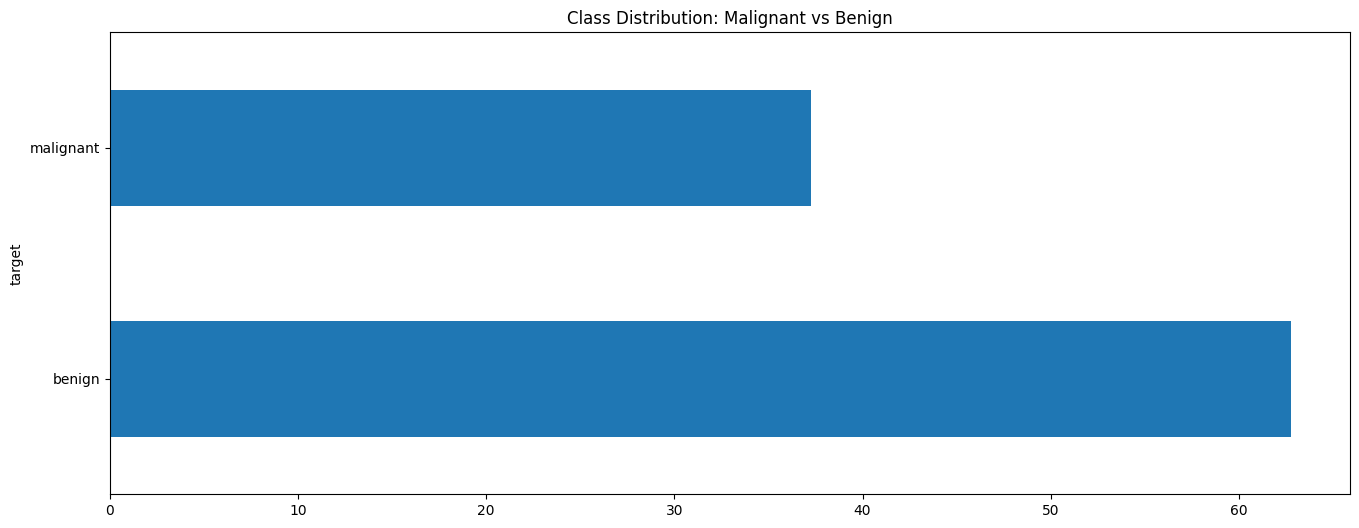

In [142]:
print(y.value_counts())
print(normalized_value_counts)

plt.figure(figsize=(16, 6))
normalized_value_counts.plot(kind='barh')
plt.title('Class Distribution: Malignant vs Benign')
plt.yticks([0, 1], ['benign', 'malignant']);

## T3 - Visualise Feature Distributions by Class

I'm comparing feature distributions between malignant and benign in order to recognize which features influence each target most and which ones least.

I will be looking for features that have a noticeable difference in data between the two targets, those will be the main features I should pay attention to in later analysis.

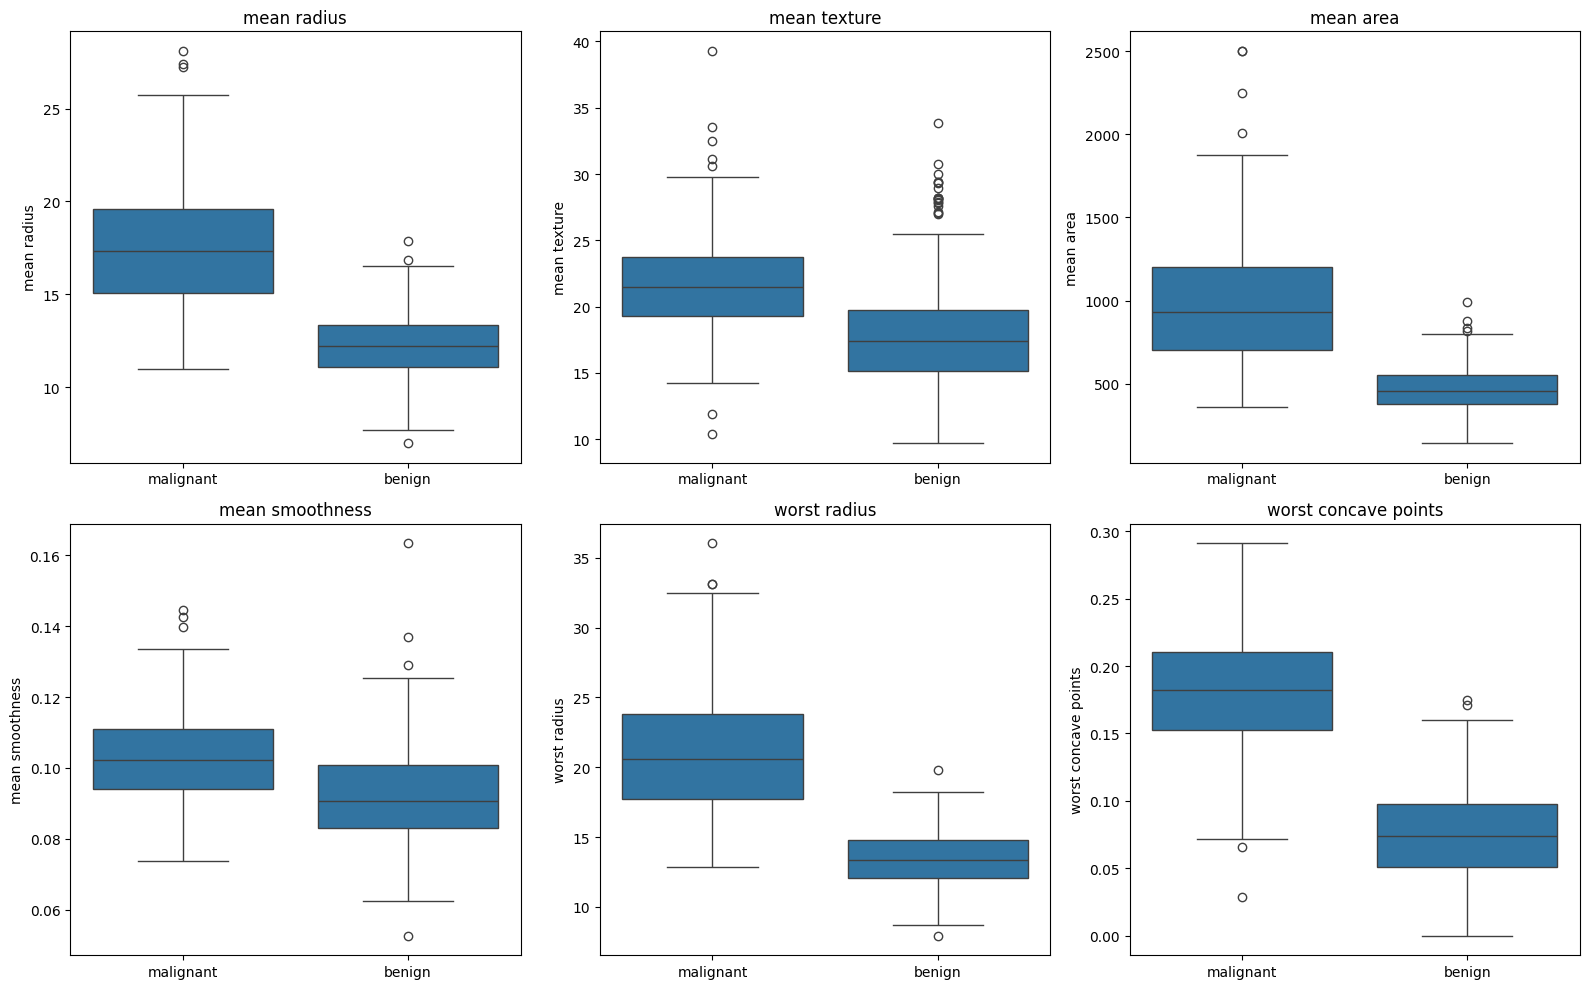

In [143]:
features = ['mean radius', 'mean texture', 'mean area', 'mean smoothness', 'worst radius', 'worst concave points']
y_labeled = y.map({0: 'malignant', 1: 'benign'})

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=X, x=y_labeled, y=X[feature], ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

Worst concave points feature shows the clearest separation between malignant and benign data, with malignant scoring noticeably higher mean than benign. This will be useful for the model, since the data is separated and clearly points to different targets depending on concave points.

Mean smoothness has the most overlap, with malignant and benign cells having almost exact mean, benign being slightly lower on the scale. This data will be less useful, the similarity between scores will confuse the model.

## T4 - Split Data into Training and Test Sets

We must use different data for training and test. Here's an analogy - if I practice for a math test and write the exact same test on my finals I'm not actually learning anything, but I will always have a score of 100%. Same goes for our model - it must have a different test set from the train set to gauge the model training effects.

Using same data for train and test would be confusing, we would not know if the model generalises to new data - it could score 95% on training and we'd have no idea if that's because it learned the pattern or just memorised it.

We split the data defining `20%` of dataset used for test. During `train_test_split` as mentioned - 0.2 goes to test, 0.8 goes to training - the data is first randomized ( we don't want to split data if it's sorted ), random_state=42 sets our random "token" meaning we get the same split output every time if we use the same token.

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [ ]:
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)

## T5 - Train a Decision Tree

A Decision Tree asks a yes/no question about a feature at each step - for example "is mean radius > 15?" If yes, go left. If no, go right. It keeps splitting until it can confidently assign a class label. The "tree" is just all those if/else branches stacked up.

If a tree keeps splitting until every sample is perfectly classified it might score 100% on training data but fail on new data because it didn't learn general patterns. That's called overfitting.

Train accuracy is 1.0 (100%) and test accuracy is 0.947 (94.7%). That gap is exactly what overfitting looks like numerically. The model memorised every training sample perfectly, but when it saw new data, it made mistakes on about 6 rows out of 114.

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [147]:
print(accuracy_score(y_test, y_pred_dt))
print(accuracy_score(y_train, dt.predict(X_train)))


0.9473684210526315
1.0


## T6 - Confusion Matrix: Decision Tree

A confusion matrix is a table that shows you exactly how many predictions fell into each of the four categories:

- TP (True Positive, correctly predicted positive)
- TN (True Negative, correctly predicted negative)
- FP (False Positive, incorrectly predicted positive)
- FN (False Negative, incorrectly predicted negative)

Instead of providing a single accuracy score, it shows the exact types of mistakes the model makes.

TP and TN are correct predictions. FP means the model identified something as positive when it was actually negative. This can be inconvenient because it may trigger unnecessary follow-up actions or inspections.

FN means the model classified something as negative when it was actually positive. In this dataset, FN is more serious because a malignant cell is incorrectly classified as benign. The threat remains undetected, potentially sending the patient home with cancer.

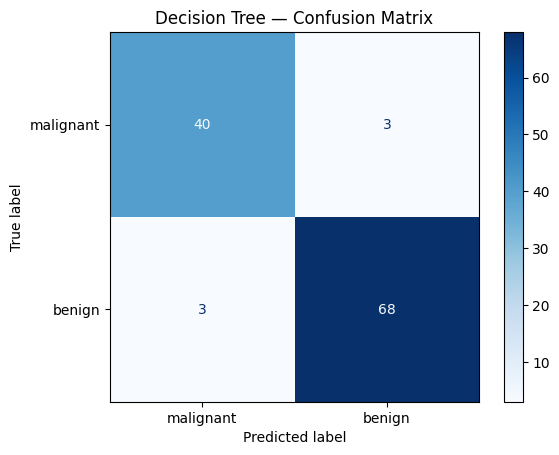

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

## T7 - Precision, Recall, and F1: Decision Tree

Both of the metrics below focus only on the positive class ( malignant in this case )

- Precision: Of all the cases the model predicted as malignant, how many actually were?
- Recall: Of all the cases that actually were malignant, how many did the model catch?

- High precision: Few false alarms ( less FP )
- High recall: Few missed cancers ( less FN )

In cancer detection high recall is more important, less False Negatives means less cancer bearing patients will go home untreated. False negative is more dangerous than false positive.

F1 is a single number that combines precision and recall. It's the harmonic mean of the two - it's high only when both precision and recall are high. You use it when you care about both metrics but need to compare models with a single score.

Actual malignant cases: 43, meaning model missed 3

In [149]:
print(classification_report(y_test, y_pred_dt, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## T8 - Train a Random Forest and Evaluate It

Decision trees overfit - being trained on a piece of data they have high variance - meaning depending on the data they are trained on their output will change, but their bias is low - meaning on the trained piece of data they're correct most times.

If we group decision trees ( for example 100 of them ) we can ask them to vote on an answer, each tree is trained on a different piece of data, each has low bias and high variance, the majority of them will vote on a result close to the actual result.

If we ask 100 people to categorize how much a rock weighs - 20kg or 200kg the majority of their responses will be right.

Random forest will decrease between the train and test data results compared to the Decision Tree.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [151]:
print(accuracy_score(y_test, y_pred_rf))
print(accuracy_score(y_train, rf.predict(X_train)))


0.9649122807017544
1.0


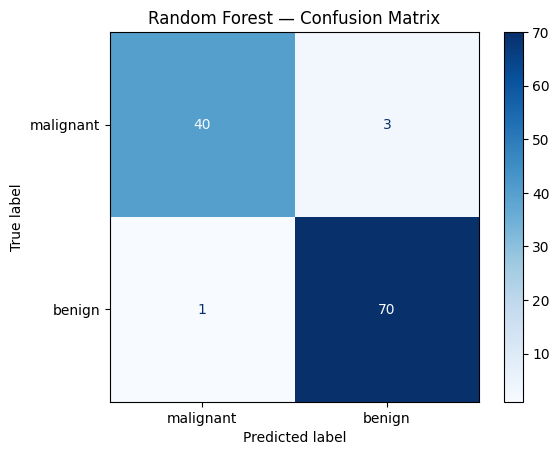

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.show()

In [153]:
print(classification_report(y_test, y_pred_rf, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## T9 - Decision Tree vs Random Forest

Random forest noticeably improved the precision in malignant cell detection (93% → 97.6%). The RF improved recall in the benign cells by 3%. This made the number of FP drop from 3 to 1 in the dataset and overall F1 score to improve by 1% point. Recall unfortunately has not been changed by the RF model in the malignant cells, with the score staying at a steady 93%. This was the most important metric, unfortunately the new model did not change it.

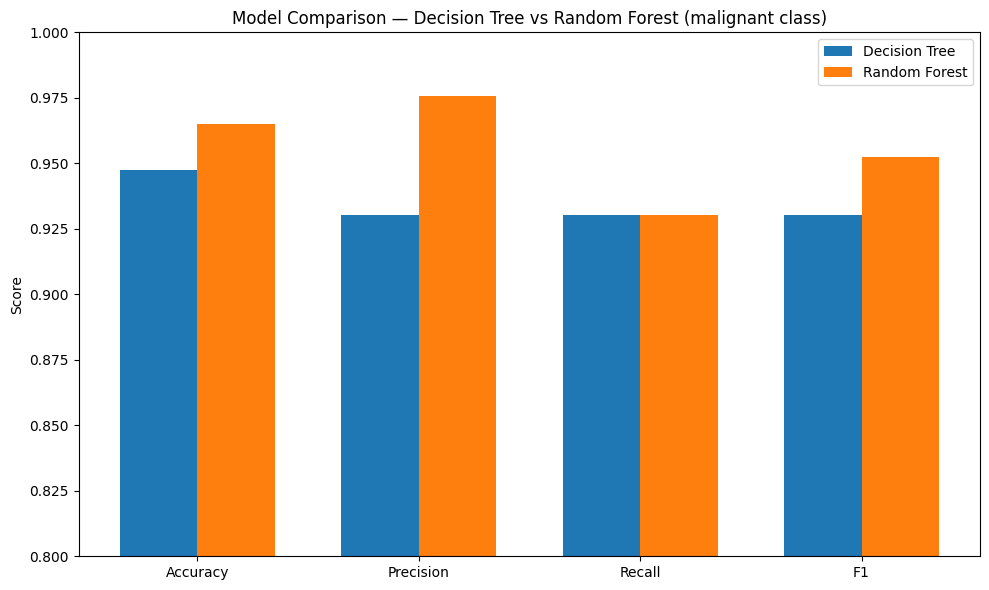

        Model  Accuracy  Precision   Recall       F1
Decision Tree  0.947368   0.930233 0.930233 0.930233
Random Forest  0.964912   0.975610 0.930233 0.952381


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model':     ['Decision Tree', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, y_pred_dt),  accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_dt, pos_label=0), precision_score(y_test, y_pred_rf, pos_label=0)],
    'Recall':    [recall_score(y_test, y_pred_dt,    pos_label=0), recall_score(y_test, y_pred_rf,    pos_label=0)],
    'F1':        [f1_score(y_test, y_pred_dt,        pos_label=0), f1_score(y_test, y_pred_rf,        pos_label=0)],
})

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width / 2, results.loc[0, metrics], width, label='Decision Tree')
ax.bar(x + width / 2, results.loc[1, metrics], width, label='Random Forest')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison - Decision Tree vs Random Forest (malignant class)')
ax.legend()
plt.tight_layout()
plt.show()

print(results.to_string(index=False))

## T10 - Feature Importance and Deployment Decision

Each feature has an importance, if it influences the output more, it is more important, if it has no effect on the final output, its importance is closer to none. If measuring importance of color in car speed classification we can safely assume the feature: color has low importance ( of course the car color will not affect its speed! or will it? ).

If I found out worst concave points is the most important feature - I'd make sure I'm measuring it accurately and consistently. If it's the most important feature, errors in that measurement would hurt my predictions more than errors in less important features.

Feature importance tells us which features you could potentially drop without hurting the model much. If mean smoothness has near-zero importance, collecting that measurement is wasted effort.

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importances.index, importances.values)
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

In this particular scenario I would deploy the Random Forest model since it has higher accuracy, precision and F1 score.

Random Forest yields higher results in:

- Precision ( malignant )
- Recall ( benign )
- Overall precision

RF is better overall, but it doesn't actually improve the metric that matters most - recall ( malignant ). This means that the model fails to recognize false negatives in malignant cancer cells.

Recall measures false negatives, it is the more important metric in cancer detection, having this score low will result in a sick patient being sent home, a lot more dangerous, than false positive.

In production it is worth monitoring feature importance, making sure the data is correctly collected. It is also worth noting precision, recall and accuracy of the model and constantly analyzing it.

Both models have been trained on non-real life data, without serious anomalies. Both Decision Tree and Random Forest models fail to correctly increase the recall score making this model too imprecise for production environments.

Both models give a hard prediction ( 0 or 1 ) but don't tell us how confident they are. A patient the model is 51% sure is benign gets the same prediction as one it's 99% sure about. In a real screening tool, we'd want to know that confidence score.